In [1]:
# !pip install triton

import torch
import triton
import triton.language as tl

# Verify GPU is available
assert torch.cuda.is_available(), "No GPU found — switch to a T4 runtime in Colab"
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Triton version: {triton.__version__}")

GPU: NVIDIA GeForce RTX 4090
Triton version: 3.6.0


In [2]:
# The full kernel
import torch
import triton
import triton.language as tl


@triton.jit
def add_kernel(
    x_ptr,      # Pointer to first input vector
    y_ptr,      # Pointer to second input vector
    output_ptr, # Pointer to output vector
    n_elements, # Total number of elements
    BLOCK_SIZE: tl.constexpr,  # Number of elements each program processes
):
    # Which program am I? (like: which chunk of work am I responsible for?)
    pid = tl.program_id(axis=0)

    # Calculate the starting index for this program's chunk
    block_start = pid * BLOCK_SIZE

    # Create offsets: [block_start, block_start+1, ..., block_start+BLOCK_SIZE-1]
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    # Mask: don't load/store beyond the end of the array
    mask = offsets < n_elements

    # Load data from global memory (with mask for safety)
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)

    # Compute
    output = x + y

    # Store result back to global memory
    tl.store(output_ptr + offsets, output, mask=mask)


In [3]:
import torch
import triton
import triton.language as tl

@triton.jit
def add_kernel(
    x_ptr, # pointer to the first input vector
    y_ptr, # pointer to the second input vector
    output_ptr, # pointer to the output vector
    n_elements, # total number of elements
    BLOCK_SIZE: tl.constexpr, # number of elements each program process
):
    # which program am i?
    pid=tl.program_id(axis=0) # returns the program's index along the first (and in this case only) axis of the launch grid

    # calculate the starting index for this program's chunk
    # if each program is responsible for BLOCK_SIZE consecutive elemmnts, this is the start of the elements for which program pid-th is responsible
    block_start=pid*BLOCK_SIZE
    # tl.arange creates a tensor of integers (not an iterator) to be added to block_start - offset, in the end, is a vector (constant + vector)
    offsets=block_start+tl.arange(0, BLOCK_SIZE)

    # mask (to prevent out-of-bounds access)
    mask=offsets<n_elements
    # For a certain size of array, I might need a certain number of blocks. The last might go beyond the size of the array. the mask is an array of Trues and Falses

    # loading the data fro global memory:
    x=tl.load(x_ptr+offsets, mask=mask)
    y=tl.load(y_ptr+offsets, mask=mask)

    # addition
    output=x+y
    # little math vs amount of moved memory - vector addition is memory bound (the gpu compute units barely work. They spend most time waiting for data)

    # store the result (writes back to global memory):
    tl.store(output_ptr+offsets, output, mask=mask)

# LAUNCHER FUNCTION
def add(x: torch.Tensor, y: torch.Tensor)-> torch.Tensor:
    # validate inputs
    assert x.is_cuda and y.is_cuda, "Inputs must be on GPU"
    assert x.shape==y.shape, "Inputs must have the same shape"

    # we use empty_like because the kernel will write to every single element of the output - prefilling with zero is wasted work (a pointless extra kernel launch) - empty_like allocates memory without initializing it
    output=torch.empty_like(x)
    n_elements=output.numel()

    # Calculate grid size - how many programs to launch
    #triton.cdiv is triton's ceiling division. It will create a grid with enough blocks to cover and exceed the vector (hence the maskign)
    # grid lambda: the grid is a function (lambda) that takes a meta dictionary and returns a tuple of integers. It's a function because Triton's autotuning is such that when using it BLOCK_SIZE is not known until triton picks the best config at runtime. lambda lets triton pass block_size through meta['BLOCK_SIZE'] and compute the correct grid size.
    # For now we have hardcoded BLOCK_SIZE=1024, so the lambda returns always the same result, but good habit to introduce the grid lambda pattern from the start.


    grid=lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)

    # Launch the kernel
    # the grid launch syntax. This is triton's way to launch a kernel.
    # [grid] says how many programs to launch (the grid configuration)
    # the rest are the arguments to pass to each instance. Pytorch tensors are automatically converted to pointers.
    # all program instances start in parallel working on the GPU. The cpu doesn't wait for them to finish (kernel launch is asynchronous), However, when use output in Pytorch, cuda's stream synchronization ensures that the kernel has completed.
    add_kernel[grid](x,y, output, n_elements, BLOCK_SIZE=1024)
    return output


In [4]:
# putting it all together
import torch
import triton
import triton.language as tl

@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr,
):
    pid=tl.program_id(axis=0)
    block_start=BLOCK_SIZE*pid
    offsets=block_start+tl.arange(0, BLOCK_SIZE)
    mask=offsets<n_elements

    x=tl.load(x_ptr+offsets, mask=mask)
    y=tl.load(y_ptr+offsets, mask=mask)

    output=x+y

    tl.store(output_ptr+offsets, output, mask=mask)

def add(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    assert x.is_cuda and y.is_cuda, "Inputs must be on GPU"
    assert x.shape==y.shape, "Inputs must have the same shape"

    output=torch.empty_like(x)
    n_elements=output.numel()

    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    add_kernel[grid](x,y, output, n_elements, BLOCK_SIZE=1024)
    return output

# --verify correctness --#
size=2**20
x=torch.rand(size, device="cuda")
y=torch.rand(size, device="cuda")

triton_output=add(x,y)
torch_output=x+y
assert torch.allclose(triton_output, torch_output), "Results don't match!"
print("Correctness verified")

Correctness verified


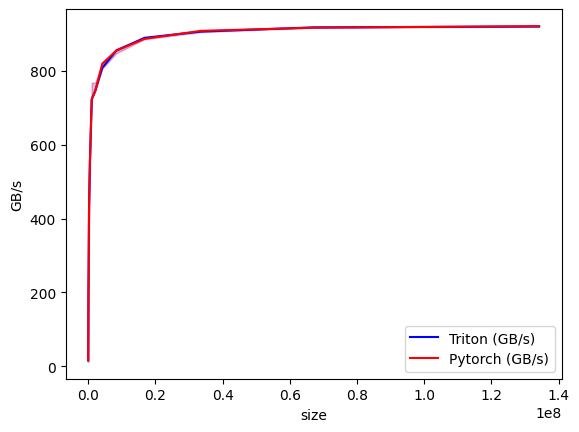

vector-addition-performance:
           size  Triton (GB/s)  Pytorch (GB/s)
0        4096.0      15.999999       15.999999
1        8192.0      31.999999       31.999999
2       16384.0      59.650486       59.362320
3       32768.0      96.000000       96.000000
4       65536.0     182.044451      187.603063
5      131072.0     255.999991      255.999991
6      262144.0     438.857137      438.857137
7      524288.0     558.545450      558.545450
8     1048576.0     722.823517      722.823517
9     2097152.0     746.140422      744.727267
10    4194304.0     807.839737      819.200021
11    8388608.0     854.817372      854.817372
12   16777216.0     889.251720      886.432699
13   33554432.0     906.027677      908.120075
14   67108864.0     917.556569      916.587398
15  134217728.0     919.803518      920.880580


In [5]:
# Benchmarking (Triton vs pytorch)
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'], #Parameter to vary,
        x_vals=[2**i for i in range(12, 28)], #4k to 128m elements
        line_arg="provider", # argument that selects the implementation
        line_vals=['triton', 'torch'],# Implementations to compare
        line_names=["Triton", "Pytorch"], # Legend Labels
        styles=[("blue", "-"), ("red", "-")], # Line styles
        ylabel='GB/s', #Y-axis label
        plot_name="vector-addition-performance", #Output file name
        args={}, # extra arguments (none here)

    )
)
def benchmark(size, provider):
    x = torch.rand(size, device='cuda', dtype=torch.float32)
    y = torch.rand(size, device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    # Calculate throughput in GB/s
    gbps = lambda ms: 3 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True)

Correctness verified


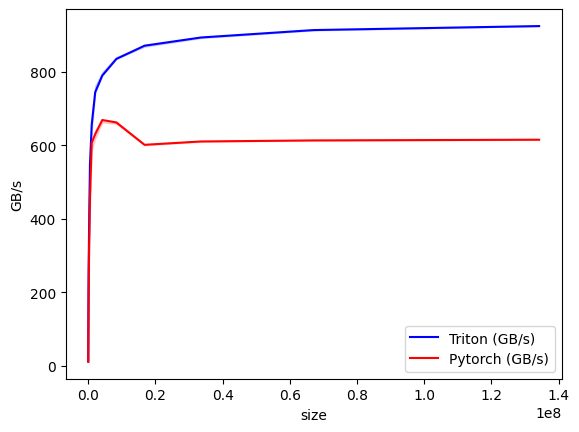

vector-addition-performance:
           size  Triton (GB/s)  Pytorch (GB/s)
0        4096.0      12.800000       10.666666
1        8192.0      21.333333       22.629835
2       16384.0      42.666665       42.666665
3       32768.0      85.333330       85.333330
4       65536.0     146.285712      128.000000
5      131072.0     256.000001      204.800005
6      262144.0     372.363633      315.076927
7      524288.0     546.133347      455.111095
8     1048576.0     655.360017      606.814814
9     2097152.0     744.727267      630.153853
10    4194304.0     789.590371      668.734716
11    8388608.0     834.853491      661.979817
12   16777216.0     870.910320      601.247704
13   33554432.0     893.165266      610.346900
14   67108864.0     913.393720      613.202346
15  134217728.0     924.262651      615.124591


In [7]:
# Triple sum
import torch
import triton
import triton.language as tl

@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    w_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr,
):
    pid=tl.program_id(axis=0)
    block_start=BLOCK_SIZE*pid
    offsets=block_start+tl.arange(0, BLOCK_SIZE)
    mask=offsets<n_elements

    x=tl.load(x_ptr+offsets, mask=mask)
    y=tl.load(y_ptr+offsets, mask=mask)
    w=tl.load(w_ptr+offsets, mask=mask)


    output=x+y+w

    tl.store(output_ptr+offsets, output, mask=mask)

def add(x: torch.Tensor, y: torch.Tensor, w: torch.Tensor) -> torch.Tensor:
    assert x.is_cuda and y.is_cuda and w.is_cuda, "Inputs must be on GPU"
    assert x.shape==y.shape==w.shape, "Inputs must have the same shape"

    output=torch.empty_like(x)
    n_elements=output.numel()

    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    add_kernel[grid](x,y,w, output, n_elements, BLOCK_SIZE=8192)
    return output

# --verify correctness --#
size=2**20
x=torch.rand(size, device="cuda")
y=torch.rand(size, device="cuda")
w=torch.rand(size, device="cuda")


triton_output=add(x,y,w)
torch_output=x+y+w
assert torch.allclose(triton_output, torch_output), "Results don't match!"
print("Correctness verified")

# Benchmarking (Triton vs pytorch)
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'], #Parameter to vary,
        x_vals=[2**i for i in range(12, 28)], #4k to 128m elements
        line_arg="provider", # argument that selects the implementation
        line_vals=['triton', 'torch'],# Implementations to compare
        line_names=["Triton", "Pytorch"], # Legend Labels
        styles=[("blue", "-"), ("red", "-")], # Line styles
        ylabel='GB/s', #Y-axis label
        plot_name="vector-addition-performance", #Output file name
        args={}, # extra arguments (none here)

    )
)
def benchmark(size, provider):
    x = torch.rand(size, device='cuda', dtype=torch.float32)
    y = torch.rand(size, device='cuda', dtype=torch.float32)
    w = torch.rand(size, device="cuda", dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y + w, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y, w), quantiles=quantiles)
    # Calculate throughput in GB/s
    gbps = lambda ms: 4 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True)